### Regresión espacial
### Modelos autoregresivos simultáneos (SAR)

In [1]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from libpysal import weights
from libpysal.weights import lag_spatial
from esda.moran import Moran

import spreg

In [2]:
# ============================================================
# 2. CARGA Y PREPARACIÓN
# ============================================================

ruta = r"carto\cuencas_gauss.gpkg"

cuencas = gpd.read_file(ruta)

# Si HYBAS_ID existe, lo usamos como índice
if "HYBAS_ID" in cuencas.columns:
    cuencas = cuencas.set_index("HYBAS_ID")

# Reproyectar correctamente
if cuencas.crs is None:
    raise ValueError("La capa no tiene CRS definido.")

cuencas = cuencas.to_crs(epsg=9377)

# Variables del modelo
var_y = "FRA"

predictoras_modelo = [
    "area[km2]",
    "Beta_media",
    "Beta_std"
]

cols = [var_y] + predictoras_modelo

gdf_model = cuencas[cols + ["geometry"]].copy()

# Convertir a numérico
for c in cols:
    gdf_model[c] = pd.to_numeric(gdf_model[c], errors="coerce")

gdf_model = gdf_model.replace([np.inf, -np.inf], np.nan)
gdf_model = gdf_model.dropna(subset=cols + ["geometry"]).copy()

# Filtrar FRA válido
gdf_model = gdf_model[
    (gdf_model["FRA"] >= 0) &
    (gdf_model["FRA"] <= 1)
].copy()

# Reset index para evitar problemas con PySAL
gdf_model = gdf_model.reset_index()

print("Número de cuencas:", len(gdf_model))
gdf_model[cols].describe()

Número de cuencas: 72


,FRA,area[km2],Beta_media,Beta_std
count,72.000000,72.000000,72.000000,72.000000
mean,0.707783,816.247564,-0.571889,0.100958
std,0.140708,628.997333,0.044738,0.072529
min,0.510000,39.711428,-0.647000,0.000000
25%,0.585000,312.474535,-0.609250,0.042500
50%,0.690000,611.165076,-0.576500,0.081000
75%,0.812500,1221.198109,-0.538500,0.146250
max,1.000000,2643.589343,-0.420000,0.323000


In [3]:
# ============================================================
# 3. MATRIZ DE VECINDAD QUEEN
# ============================================================

w_queen = weights.Queen.from_dataframe(gdf_model, use_index=False)
w_queen.transform = "R"

print("Número de islas:", len(w_queen.islands))
print("Islas:", w_queen.islands)
print("Promedio de vecinos:", np.mean(list(w_queen.cardinalities.values())))

Número de islas: 0
Islas: []
Promedio de vecinos: 3.9722222222222223


In [4]:
# ============================================================
# 4. VARIABLE RESPUESTA Y PREDICTORAS
# ============================================================

y = gdf_model[var_y].values.reshape((-1, 1))

X_raw = gdf_model[predictoras_modelo].copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_raw)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=predictoras_modelo,
    index=gdf_model.index
)

In [5]:
# ============================================================
# 5. OLS BASE CON DIAGNÓSTICOS ESPACIALES
# ============================================================

ols_base = spreg.OLS(
    y,
    X_scaled,
    w=w_queen,
    name_y="FRA",
    name_x=predictoras_modelo,
    name_w="Queen",
    spat_diag=True,
    moran=True
)

print(ols_base.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :       Queen
Dependent Variable  :         FRA                Number of Observations:          72
Mean dependent var  :      0.7078                Number of Variables   :           4
S.D. dependent var  :      0.1407                Degrees of Freedom    :          68
R-squared           :      0.7838
Adjusted R-squared  :      0.7742
Sum squared residual:    0.303973                F-statistic           :     82.1550
Sigma-square        :       0.004                Prob(F-statistic)     :   1.444e-22
S.E. of regression  :       0.067                Log likelihood        :      94.666
Sigma-square ML     :       0.004                Akaike info criterion :    -181.332
S.E of regression ML:      0.0650                Schwarz criterion     :    -172.225

-----------------

### Modelo SLX incorporando spatial lag de las variables predictivas
Se incorporaron solo las variables que resultaron estadísticamente significativas anteriormente

In [6]:
# ============================================================
# 6. SLX - SPATIALLY LAGGED X
# ============================================================

wx_dict = {}

for var in predictoras_modelo:
    wx_dict[f"W_{var}"] = lag_spatial(
        w_queen,
        X_scaled_df[var].values
    )

WX_df = pd.DataFrame(
    wx_dict,
    index=gdf_model.index
)

X_slx_df = pd.concat(
    [X_scaled_df, WX_df],
    axis=1
)

slx_model = spreg.OLS(
    y,
    X_slx_df.values,
    w=w_queen,
    name_y="FRA",
    name_x=X_slx_df.columns.tolist(),
    name_w="Queen",
    spat_diag=True,
    moran=True
)

print(slx_model.name_x)
print(slx_model.summary)

['CONSTANT', 'area[km2]', 'Beta_media', 'Beta_std', 'W_area[km2]', 'W_Beta_media', 'W_Beta_std']
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :       Queen
Dependent Variable  :         FRA                Number of Observations:          72
Mean dependent var  :      0.7078                Number of Variables   :           7
S.D. dependent var  :      0.1407                Degrees of Freedom    :          65
R-squared           :      0.8083
Adjusted R-squared  :      0.7906
Sum squared residual:    0.269482                F-statistic           :     45.6772
Sigma-square        :       0.004                Prob(F-statistic)     :   1.856e-21
S.E. of regression  :       0.064                Log likelihood        :      99.001
Sigma-square ML     :       0.004                Akaike info criterion :    -184.003
S.E of

In [7]:
# ============================================================
# TABLA LIMPIA DE COEFICIENTES DEL SLX
# ============================================================

coef_slx = pd.DataFrame({
    "Variable": slx_model.name_x,
    "Coeficiente": slx_model.betas.flatten(),
    "Std_Error": slx_model.std_err
})

# spreg guarda t_stat como lista de tuplas: (t, p-value)
coef_slx["t_stat"] = [x[0] for x in slx_model.t_stat]
coef_slx["p_value"] = [x[1] for x in slx_model.t_stat]

display(coef_slx.round(5))

,Variable,Coeficiente,Std_Error,t_stat,p_value
0,CONSTANT,0.70740,0.00869,81.37270,0.00000
1,area[km2],-0.04729,0.00914,-5.17344,0.00000
2,Beta_media,0.03881,0.01149,3.37890,0.00123
3,Beta_std,0.10039,0.01013,9.90794,0.00000
4,W_area[km2],0.02838,0.01368,2.07401,0.04204
5,W_Beta_media,-0.01883,0.01742,-1.08130,0.28356
6,W_Beta_std,0.03095,0.01935,1.59892,0.11469


### Modelo SEM: autocorrelación endogena con el error espacial
Lambda no es estadísticamente significativa, por esto no se encuentra dependencia espacial en el error

In [8]:
# ============================================================
# 7. SEM - SPATIAL ERROR MODEL
# ============================================================

sem_model = spreg.GM_Error_Het(
    y,
    X_scaled,
    w=w_queen,
    name_y="FRA",
    name_x=predictoras_modelo,
    name_w="Queen"
)

print(sem_model.summary)

GM_Error_Het
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES (HET)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :       Queen
Dependent Variable  :         FRA                Number of Observations:          72
Mean dependent var  :      0.7078                Number of Variables   :           4
S.D. dependent var  :      0.1407                Degrees of Freedom    :          68
Pseudo R-squared    :      0.7831
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.70867         0.00952        74.47554         0.00000
           area[km2

### Modelo SAR: autocorrelación endógena de la variable dependiente

In [9]:
# ============================================================
# 8. SAR-LAG - SPATIAL LAG MODEL
# ============================================================

sar_lag_model = spreg.GM_Lag(
    y,
    X_scaled,
    w=w_queen,
    name_y="FRA",
    name_x=predictoras_modelo,
    name_w="Queen"
)

print(sar_lag_model.summary)

GM_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :       Queen
Dependent Variable  :         FRA                Number of Observations:          72
Mean dependent var  :      0.7078                Number of Variables   :           5
S.D. dependent var  :      0.1407                Degrees of Freedom    :          67
Pseudo R-squared    :      0.7848
Spatial Pseudo R-squared:  0.7828

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.65607         0.07113         9.22326         0.00000
           area[km2]        -0.04231         0.00905        -4.67686         0.00000
 

In [10]:
# ============================================================
# 9. COMPARACIÓN DE MODELOS
# ============================================================

def evaluar_modelo_spreg(nombre, modelo, w):
    y_obs = y.flatten()
    y_pred = np.asarray(modelo.predy).flatten()
    resid = np.asarray(modelo.u).flatten()

    r2 = r2_score(y_obs, y_pred)
    mae = mean_absolute_error(y_obs, y_pred)
    rmse = np.sqrt(mean_squared_error(y_obs, y_pred))

    moran_res = Moran(
        resid,
        w,
        permutations=999
    )

    return {
        "Modelo": nombre,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Moran_residuos": moran_res.I,
        "p_Moran_residuos": moran_res.p_sim
    }


comparacion_python = pd.DataFrame([
    evaluar_modelo_spreg("OLS", ols_base, w_queen),
    evaluar_modelo_spreg("SLX", slx_model, w_queen),
    evaluar_modelo_spreg("SEM", sem_model, w_queen),
    evaluar_modelo_spreg("SAR-Lag", sar_lag_model, w_queen)
])

comparacion_python

,Modelo,R2,MAE,RMSE,Moran_residuos,p_Moran_residuos
0,OLS,0.783760,0.046290,0.064976,0.064185,0.183
1,SLX,0.808295,0.043944,0.061179,-0.018075,0.486
2,SEM,0.783060,0.047223,0.065081,0.088547,0.093
3,SAR-Lag,0.784770,0.045537,0.064824,0.025630,0.322


In [11]:
# ============================================================
# 10. GUARDAR PREDICCIONES Y RESIDUOS
# ============================================================

gdf_model["pred_OLS"] = np.asarray(ols_base.predy).flatten()
gdf_model["res_OLS"] = np.asarray(ols_base.u).flatten()

gdf_model["pred_SLX"] = np.asarray(slx_model.predy).flatten()
gdf_model["res_SLX"] = np.asarray(slx_model.u).flatten()

gdf_model["pred_SEM"] = np.asarray(sem_model.predy).flatten()
gdf_model["res_SEM"] = np.asarray(sem_model.u).flatten()

gdf_model["pred_SAR_Lag"] = np.asarray(sar_lag_model.predy).flatten()
gdf_model["res_SAR_Lag"] = np.asarray(sar_lag_model.u).flatten()

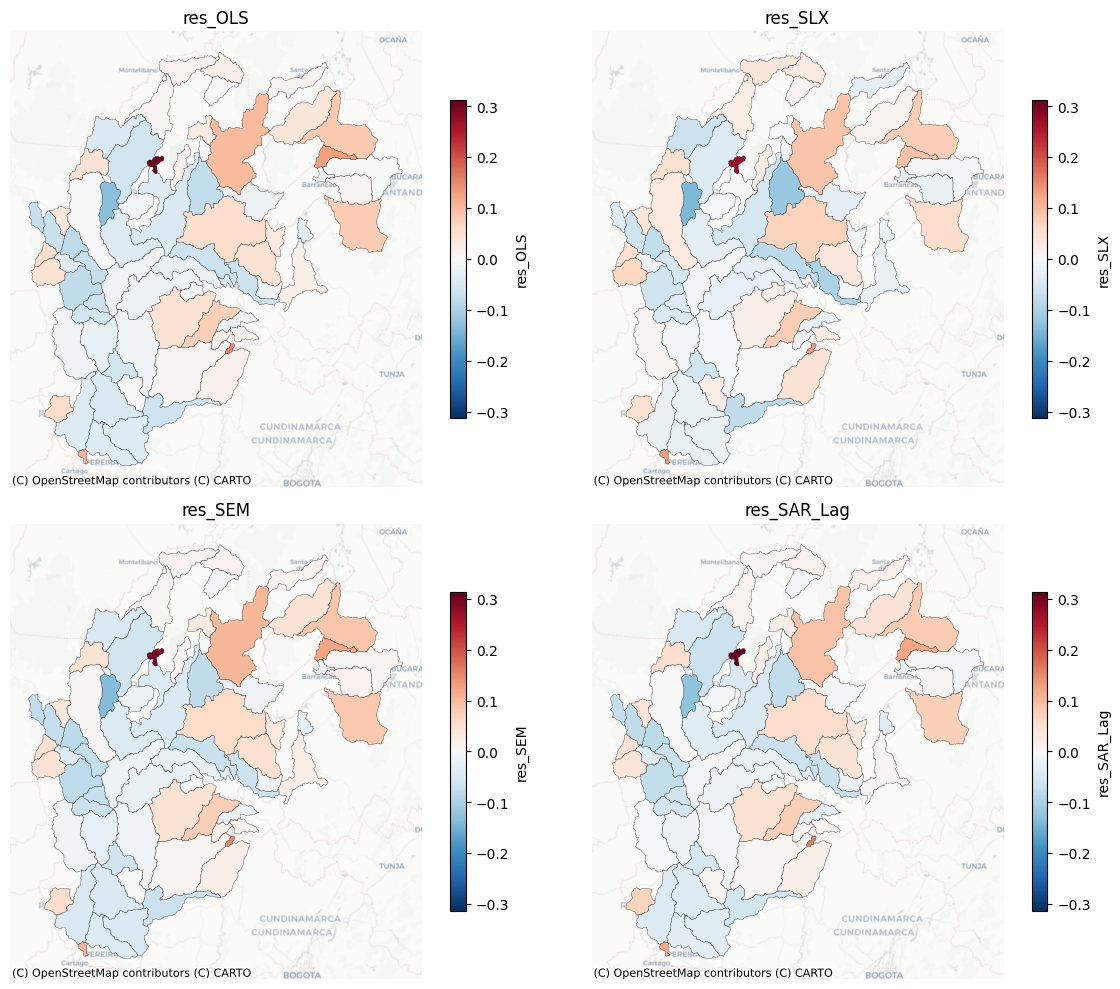

In [12]:
# ============================================================
# 11. MAPAS DE RESIDUOS
# ============================================================
import contextily as ctx
from matplotlib.colors import TwoSlopeNorm

res_cols = [
    "res_OLS",
    "res_SLX",
    "res_SEM",
    "res_SAR_Lag"
]

vmax = max(
    abs(gdf_model[res_cols].min().min()),
    abs(gdf_model[res_cols].max().max())
)

norm = TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0,
    vmax=vmax
)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax = ax.flatten()

for i, col in enumerate(res_cols):
    gdf_model.plot(
        ax=ax[i],
        column=col,
        cmap="RdBu_r",
        norm=norm,
        edgecolor="black",
        linewidth=0.2,
        legend=True,
        legend_kwds={
            "label": col,
            "shrink": 0.7
        }
    )

    ctx.add_basemap(source=ctx.providers.CartoDB.Positron,crs=gdf_model.crs,ax=ax[i])

    ax[i].set_title(col)
    ax[i].set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 12. EXPORTAR CAPA LIMPIA PARA R
# ============================================================

'''salida_r = gdf_model.copy()

salida_r = salida_r.rename(
    columns={
        "area[km2]": "area_km2"
    }
)

ruta_salida_r = r"carto\cuencas_sar_R.gpkg"

salida_r.to_file(
    ruta_salida_r,
    layer="cuencas_sar_R",
    driver="GPKG"
)

print("Archivo exportado para R:")
print(ruta_salida_r)'''

Archivo exportado para R:
carto\cuencas_sar_R.gpkg
